# Logistic Regression From Scratch — MNIST Phase 1

**Binary classification:** target digit vs all other digits.

- Internal labels: **0** (other digits), **1** (target digit).
- Display labels: **Class 1** (target digit), **Class 2** (all others).

---

## Mathematical Formulation

### Model

| Symbol | Meaning |
|--------|---------|
| $X \in \mathbb{R}^{n \times d}$ | Feature matrix ($n$ samples, $d$ features) |
| $w \in \mathbb{R}^{d}$, $b \in \mathbb{R}$ | Learnable weight vector and bias |
| $\hat{y} = \sigma(Xw + b)$ | Predicted probability that a sample belongs to Class 1 |

### Sigmoid Activation

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \Rightarrow \quad \hat{y}_i \in (0, 1)$$

### Loss Function — Binary Cross-Entropy (BCE)

$$\mathcal{L}(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

**Why BCE?**
- It is the **negative log-likelihood** of a Bernoulli distribution — minimising it equals Maximum Likelihood Estimation of $w$ and $b$.
- It penalises confident wrong predictions heavily (log diverges to $-\infty$ as $\hat{y} \to 0$ when $y=1$).

### Optimization — Batch Gradient Descent

Gradients of the loss with respect to parameters (derived analytically):

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} X^T (\hat{y} - y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum_{i=1}^{n}(\hat{y}_i - y_i)$$

Parameter update rule (one step per epoch):

$$w \leftarrow w - \alpha \frac{\partial \mathcal{L}}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b}$$

where $\alpha$ is the **learning rate** (hyperparameter).

**Why Batch GD?**
Logistic regression has no closed-form solution. Full-batch gradient descent is stable and deterministic — appropriate for this dataset size and problem.

---


## 0. Imports

Only **NumPy** and **Matplotlib** — no ML libraries used.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import preprocess_mnist



Method: flatten
X_train: (51000, 784)
X_val: (9000, 784)
X_test: (10000, 784)
y_train: (51000,)

Method: pca
PCA variance kept: 0.9147
X_train: (51000, 100)
X_val: (9000, 100)
X_test: (10000, 100)
y_train: (51000,)

Method: hog
X_train: (51000, 324)
X_val: (9000, 324)
X_test: (10000, 324)
y_train: (51000,)


## 1. Experiment Settings

Change `method` to `"flatten"`, `"pca"`, or `"hog"`.

> **Note:** Always restart the kernel and run all cells top-to-bottom before recording results.


In [2]:
target_digit    = 0
method          = "hog"   # "flatten" | "pca" | "hog"
pca_components  = 100

learning_rate   = 0.05
epochs          = 2000    # Increased from 300 to ensure full convergence


## 2. Load and Preprocess Data

Creates training, validation, and test sets. `mean` and `std` are returned so we can undo standardisation for image visualisation later.


In [3]:
X_train, y_train, X_val, y_val, X_test, y_test, mean, std = preprocess_mnist(
    target_digit=target_digit,
    method=method,
    pca_components=pca_components
)

print("Method      :", method)
print("Target digit:", target_digit)
print("X_train     :", X_train.shape)
print("X_val       :", X_val.shape)
print("X_test      :", X_test.shape)

print("\nTraining class distribution:")
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
print(f"  Class 1 (digit {target_digit}): {n_pos}")
print(f"  Class 2 (others)  : {n_neg}")
print(f"  Imbalance ratio   : 1 : {n_neg // n_pos}")


Method      : hog
Target digit: 0
X_train     : (51000, 324)
X_val       : (9000, 324)
X_test      : (10000, 324)

Training class distribution:
  Class 1 (digit 0): 5032
  Class 2 (others)  : 45968
  Imbalance ratio   : 1 : 9


## 3. Logistic Regression — Built From Scratch

All mathematics implemented manually using **NumPy only**.

### 3.1 Loss Function: Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

An `epsilon = 1e-8` guard prevents `log(0)` numerical errors.

### 3.2 Optimization: Batch Gradient Descent

At each epoch: forward pass → compute loss → compute gradients analytically → update parameters.

| Function | Formula |
|----------|---------|
| Sigmoid | $\sigma(z) = 1 / (1 + e^{-z})$ |
| Loss (BCE) | $-\frac{1}{n}\sum y\log(\hat{y}) + (1-y)\log(1-\hat{y})$ |
| $\partial\mathcal{L}/\partial w$ | $\frac{1}{n} X^T (\hat{y} - y)$ |
| $\partial\mathcal{L}/\partial b$ | $\frac{1}{n} \sum (\hat{y} - y)$ |


In [4]:
# ── Activation function ──────────────────────────────────────────────────────
def sigmoid(z):
    """Numerically stable sigmoid: sigma(z) = 1 / (1 + exp(-z))."""
    return 1.0 / (1.0 + np.exp(-z))


# ── Loss function ────────────────────────────────────────────────────────────
def compute_loss(y_true, y_pred):
    """Binary Cross-Entropy loss.

    L = -(1/n) * sum[ y*log(y_hat) + (1-y)*log(1-y_hat) ]

    epsilon guard prevents log(0) when y_hat is exactly 0 or 1.
    """
    eps = 1e-8
    return -np.mean(
        y_true * np.log(y_pred + eps) +
        (1 - y_true) * np.log(1 - y_pred + eps)
    )


# ── Forward pass ─────────────────────────────────────────────────────────────
def predict_probability(X, W, b):
    """Forward pass: P(y=1 | X) = sigmoid(X @ W + b)."""
    return sigmoid(np.dot(X, W) + b)


# ── Hard classification ───────────────────────────────────────────────────────
def predict_binary(X, W, b, threshold=0.5):
    """Threshold probabilities to hard 0/1 labels."""
    return (predict_probability(X, W, b) >= threshold).astype(int)


# ── Label converter for display ───────────────────────────────────────────────
def convert_to_class_1_class_2(predictions):
    """Map internal labels {0, 1} to Class 2 / Class 1 for display."""
    return np.where(predictions == 1, 1, 2)


## 3.3 Linearity Check — 2D PCA Projection

Projects training data into 2 principal components to visually assess linear separability.

- Each point = one MNIST image.
- **Class 1** = target digit, **Class 2** = all other digits.

> This graph is for understanding only — does **not** affect real model training.


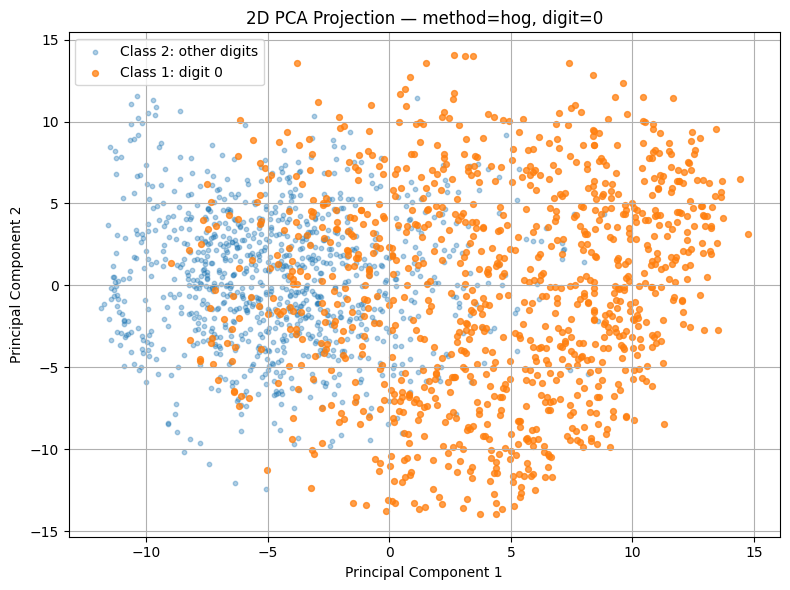

In [5]:
np.random.seed(42)
max_per_class = 1000

pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

pos_sample = np.random.choice(pos_idx, size=min(max_per_class, len(pos_idx)), replace=False)
neg_sample = np.random.choice(neg_idx, size=min(max_per_class, len(neg_idx)), replace=False)

sample_idx = np.concatenate([pos_sample, neg_sample])
np.random.shuffle(sample_idx)

X_vis = X_train[sample_idx]
y_vis = y_train[sample_idx]

# Manual PCA via SVD — no sklearn
X_centered = X_vis - np.mean(X_vis, axis=0)
_, _, Vt   = np.linalg.svd(X_centered, full_matrices=False)
X_vis_2d   = X_centered @ Vt[:2].T

plt.figure(figsize=(8, 6))
plt.scatter(X_vis_2d[y_vis == 0, 0], X_vis_2d[y_vis == 0, 1],
            s=10, alpha=0.35, label="Class 2: other digits")
plt.scatter(X_vis_2d[y_vis == 1, 0], X_vis_2d[y_vis == 1, 1],
            s=18, alpha=0.75, label=f"Class 1: digit {target_digit}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"2D PCA Projection — method={method}, digit={target_digit}")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## 3.4 Visual Linear Decision Boundary

A logistic regression trained **only on the 2D PCA axes** shows whether a straight line can separate the classes.

- Clear separation around the dashed line means more linearly separable data.
- Mixed colors across the boundary means weaker linear separability.


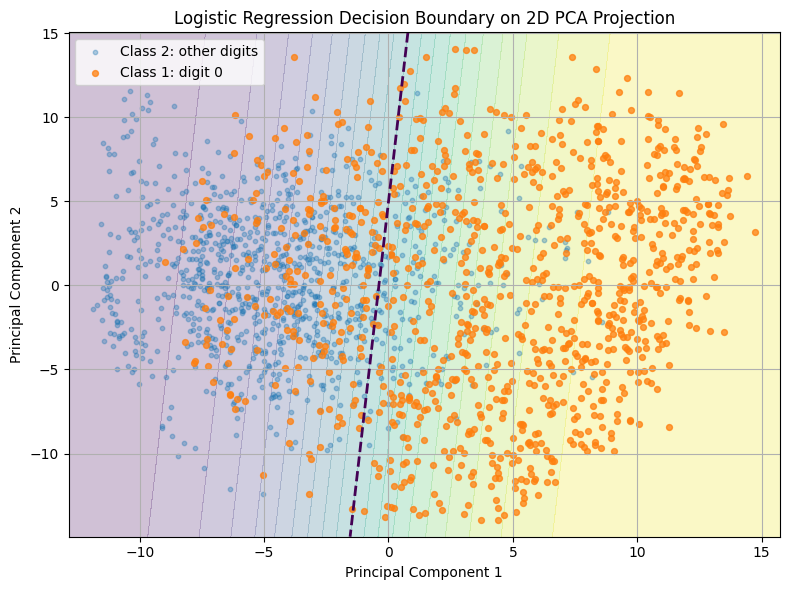

Interpretation:
  Dashed line = P(y=1) = 0.5 decision boundary
  Clear separation => more linearly separable data
  Mixed/overlapping classes => weaker linear separability


In [6]:
W_vis = np.zeros(2); b_vis = 0.0
lr_vis = 0.1; epochs_vis = 800
m_vis  = X_vis_2d.shape[0]

for _ in range(epochs_vis):
    y_vis_pred = sigmoid(X_vis_2d @ W_vis + b_vis)
    error_vis  = y_vis_pred - y_vis
    W_vis -= lr_vis * (X_vis_2d.T @ error_vis) / m_vis
    b_vis -= lr_vis * error_vis.mean()

x_min, x_max = X_vis_2d[:, 0].min() - 1, X_vis_2d[:, 0].max() + 1
y_min, y_max = X_vis_2d[:, 1].min() - 1, X_vis_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                      np.linspace(y_min, y_max, 250))
grid_probs = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ W_vis + b_vis).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_probs, levels=20, alpha=0.25)
plt.contour(xx, yy, grid_probs, levels=[0.5], linestyles="--", linewidths=2)
plt.scatter(X_vis_2d[y_vis == 0, 0], X_vis_2d[y_vis == 0, 1],
            s=10, alpha=0.35, label="Class 2: other digits")
plt.scatter(X_vis_2d[y_vis == 1, 0], X_vis_2d[y_vis == 1, 1],
            s=18, alpha=0.75, label=f"Class 1: digit {target_digit}")
plt.xlabel("Principal Component 1"); plt.ylabel("Principal Component 2")
plt.title("Logistic Regression Decision Boundary on 2D PCA Projection")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("Interpretation:")
print("  Dashed line = P(y=1) = 0.5 decision boundary")
print("  Clear separation => more linearly separable data")
print("  Mixed/overlapping classes => weaker linear separability")


## 4. Train Model — Batch Gradient Descent

### Algorithm per epoch

1. **Forward pass**: $\hat{y} = \sigma(Xw + b)$
2. **Loss**: $\mathcal{L} = \text{BCE}(y, \hat{y})$
3. **Gradients**: $\nabla_w = \frac{1}{n}X^T(\hat{y}-y)$, $\nabla_b = \frac{1}{n}\sum(\hat{y}-y)$
4. **Update**: $w \leftarrow w - \alpha\nabla_w$, $b \leftarrow b - \alpha\nabla_b$
5. **Validation loss**: monitored each epoch (no weight update)
6. **Checkpoint**: save best weights when val loss improves

Training set updates weights. Validation set only monitors generalisation.


In [7]:
m, n = X_train.shape

# Initialise weights to zero
W = np.zeros(n)
b = 0.0

train_losses = []
val_losses   = []

best_val_loss = float("inf")
best_W        = W.copy()
best_b        = b
best_epoch    = 0

for epoch in range(epochs):

    # 1. Forward pass
    y_pred     = predict_probability(X_train, W, b)
    train_loss = compute_loss(y_train, y_pred)

    # 2. Compute gradients analytically
    error = y_pred - y_train           # shape (m,)
    dW    = (X_train.T @ error) / m   # shape (d,)
    db    = error.mean()               # scalar

    # 3. Gradient descent update
    W -= learning_rate * dW
    b -= learning_rate * db

    # 4. Validation loss — weights NOT updated here
    val_pred = predict_probability(X_val, W, b)
    val_loss = compute_loss(y_val, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # 5. Model checkpointing — save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_W        = W.copy()
        best_b        = b
        best_epoch    = epoch

    if epoch % 200 == 0:
        print(f"Epoch {epoch:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Restore best weights
W = best_W
b = best_b

print("\nTraining finished.")
print(f"Best validation epoch : {best_epoch}")
print(f"Best validation loss  : {best_val_loss:.4f}")


Epoch 0000 | Train Loss: 0.6931 | Val Loss: 0.6489
Epoch 0200 | Train Loss: 0.1330 | Val Loss: 0.1312
Epoch 0400 | Train Loss: 0.0832 | Val Loss: 0.0824
Epoch 0600 | Train Loss: 0.0642 | Val Loss: 0.0637
Epoch 0800 | Train Loss: 0.0539 | Val Loss: 0.0537
Epoch 1000 | Train Loss: 0.0474 | Val Loss: 0.0473
Epoch 1200 | Train Loss: 0.0429 | Val Loss: 0.0429
Epoch 1400 | Train Loss: 0.0395 | Val Loss: 0.0396
Epoch 1600 | Train Loss: 0.0368 | Val Loss: 0.0370
Epoch 1800 | Train Loss: 0.0347 | Val Loss: 0.0349

Training finished.
Best validation epoch : 1999
Best validation loss  : 0.0333


## 5. Loss Curve

Plot training and validation BCE loss over epochs to verify convergence and detect overfitting.

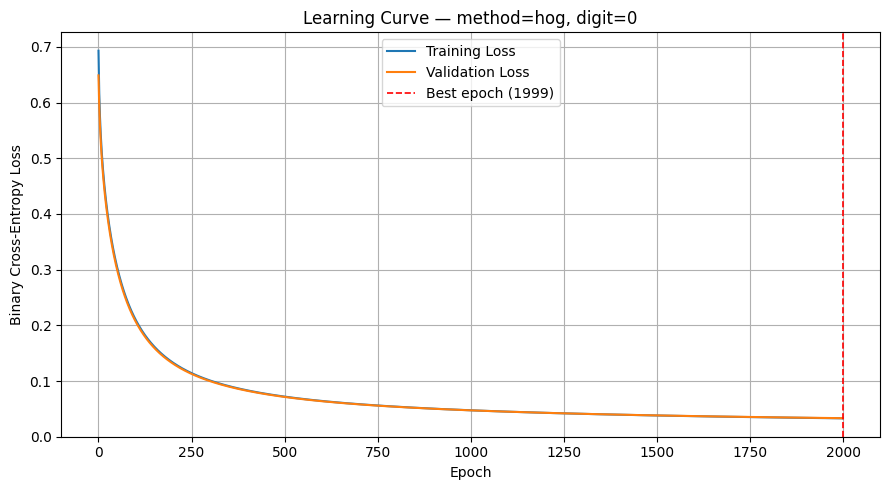

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Training Loss",   lw=1.5)
plt.plot(val_losses,   label="Validation Loss", lw=1.5)
plt.axvline(best_epoch, color="red", linestyle="--",
            label=f"Best epoch ({best_epoch})", lw=1.2)
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.title(f"Learning Curve — method={method}, digit={target_digit}")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## 6. Evaluation Metrics — Built From Scratch

All metrics computed manually from confusion-matrix counts. **No scikit-learn.**

| Metric | Formula |
|--------|---------|
| Accuracy  | $(TP + TN) / (TP + TN + FP + FN)$ |
| Precision | $TP / (TP + FP)$ |
| Recall    | $TP / (TP + FN)$ |
| F1 Score  | $2 \cdot P \cdot R \,/\, (P + R)$ |

- **TP** = predicted Class 1, actually Class 1
- **TN** = predicted Class 2, actually Class 2
- **FP** = predicted Class 1, actually Class 2 (false alarm)
- **FN** = predicted Class 2, actually Class 1 (missed detection)


In [9]:
def evaluate(y_true, y_pred):
    """Compute accuracy, precision, recall, F1, and raw confusion-matrix counts."""
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return accuracy, precision, recall, f1, TP, TN, FP, FN


## 7. Final Test Evaluation

The test set is used **only once**, after all hyperparameter choices are finalised.

In [10]:
y_test_pred       = predict_binary(X_test, W, b)
final_predictions = convert_to_class_1_class_2(y_test_pred)

accuracy, precision, recall, f1, TP, TN, FP, FN = evaluate(y_test, y_test_pred)

print("FINAL TEST RESULTS")
print("==================")
print(f"Target digit   : {target_digit}")
print(f"Class 1        : digit {target_digit}")
print(f"Class 2        : all other digits")
print(f"Feature method : {method}")
print(f"Best val epoch : {best_epoch}")
print()
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print()
print("Confusion Matrix  (Rows=Actual | Cols=Predicted)")
print("              Pred C2   Pred C1")
print(f"  Actual C2     {TN:5d}    {FP:5d}")
print(f"  Actual C1     {FN:5d}    {TP:5d}")
print()
print("First 20 predictions (Class 1 / Class 2):")
print(final_predictions[:20])
print()
print("Note: One-vs-all on MNIST has ~9% positive samples.")
print("      Low recall is expected; use handle_imbalance=True to improve it.")


FINAL TEST RESULTS
Target digit   : 0
Class 1        : digit 0
Class 2        : all other digits
Feature method : hog
Best val epoch : 1999

Accuracy  : 0.9922
Precision : 0.9556
Recall    : 0.9653
F1 Score  : 0.9604

Confusion Matrix  (Rows=Actual | Cols=Predicted)
              Pred C2   Pred C1
  Actual C2      8976       44
  Actual C1        34      946

First 20 predictions (Class 1 / Class 2):
[2 2 2 1 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2]

Note: One-vs-all on MNIST has ~9% positive samples.
      Low recall is expected; use handle_imbalance=True to improve it.


## 8. Visualise Sample Predictions

Shows test images with actual vs predicted labels. Green = correct, red = wrong.

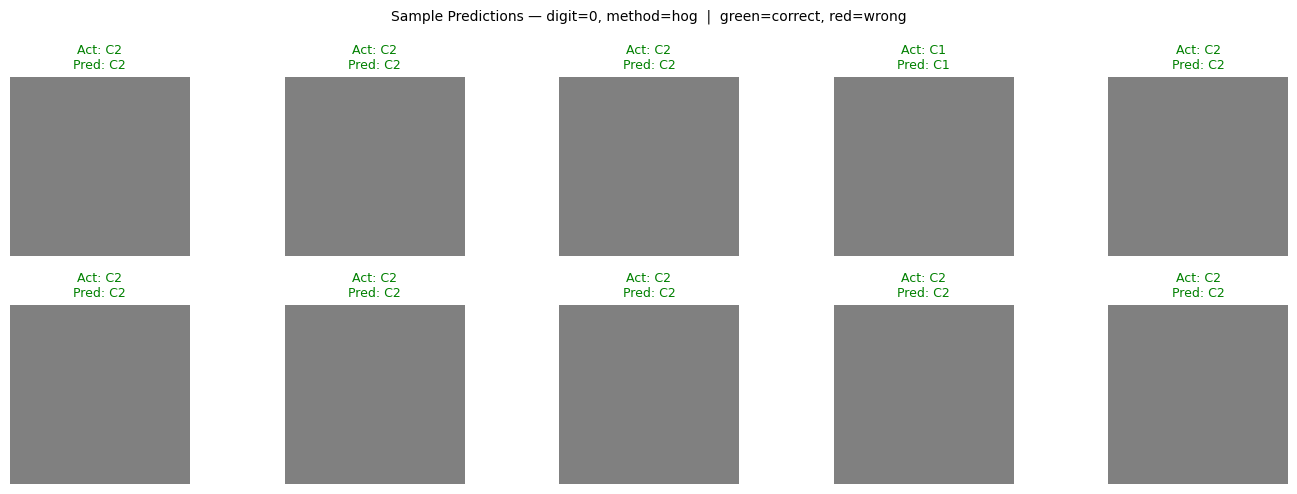

In [11]:
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    if method == "flatten":
        image = (X_test[i] * std + mean).reshape(28, 28)
    else:
        image = np.full((28, 28), 0.5)   # Placeholder for PCA / HOG

    pred_class   = int(final_predictions[i])
    actual_class = 1 if y_test[i] == 1 else 2
    color        = "green" if pred_class == actual_class else "red"

    plt.imshow(image, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Act: C{actual_class}\nPred: C{pred_class}", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle(
    f"Sample Predictions — digit={target_digit}, method={method}  |  green=correct, red=wrong",
    fontsize=10
)
plt.tight_layout(); plt.show()


## 9. Experimental Results Table

Run the notebook **three times** (one per feature method) and fill in the table.

### How to use

1. Set `method = "flatten"` -> Run all cells -> copy `results_row` values into Row 1.
2. Set `method = "pca"` -> Run all cells -> copy into Row 2.
3. Set `method = "hog"` -> Run all cells -> copy into Row 3.

### Results Table

| Model | Digit | Method | Best Epoch | Accuracy | Precision | Recall | F1 Score |
|-------|-------|--------|-----------|---------|----------|--------|---------|
| Logistic Regression | 0 | flatten | — | — | — | — | — |
| Logistic Regression | 0 | pca     | — | — | — | — | — |
| Logistic Regression | 0 | hog     | — | — | — | — | — |

> **Interpretation:**
> - **Accuracy** alone is misleading under class imbalance (~9% positive). Prefer **F1**.
> - **Recall** = fraction of actual target digits correctly identified.
> - **Precision** = fraction of predicted target digits that are truly correct.
> - **F1** balances precision and recall — use this to compare methods.


In [ ]:
# Ready-to-copy results row after each run
results_row = {
    "model"        : "Logistic Regression",
    "target_digit" : target_digit,
    "method"       : method,
    "best_epoch"   : best_epoch,
    "accuracy"     : round(float(accuracy),  4),
    "precision"    : round(float(precision), 4),
    "recall"       : round(float(recall),    4),
    "f1"           : round(float(f1),        4),
}

print(results_row)


Copy this row into your results table:
{'model': 'Logistic Regression', 'target_digit': 0, 'method': 'hog', 'best_epoch': 1999, 'accuracy': 0.9922, 'precision': 0.9556, 'recall': 0.9653, 'f1': 0.9604}
